# 1. IMPORT LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    StandardScaler,
    OrdinalEncoder,
    OneHotEncoder
)

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# 2. LOAD DATA

In [4]:
df = pd.read_csv('dataset.csv')

print("Shape:", df.shape)

display(df.head())

print("\nData Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nDescriptive Statistics:")
display(df.describe())

Shape: (5000, 13)


,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4



Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


# 3. EXPLORATORY DATA ANALYSIS (EDA)


In [5]:
# Target Distribution

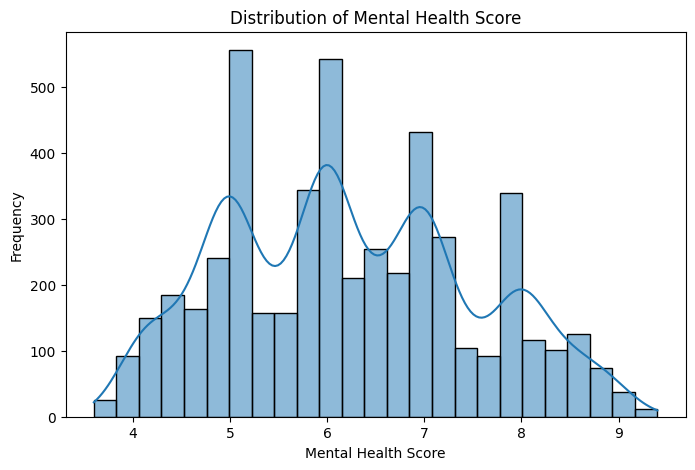

In [6]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df['Mental_Health_Score'],
    kde=True
)

plt.title('Distribution of Mental Health Score')
plt.xlabel('Mental Health Score')
plt.ylabel('Frequency')
plt.show()

In [7]:
# Correlation Heatmap

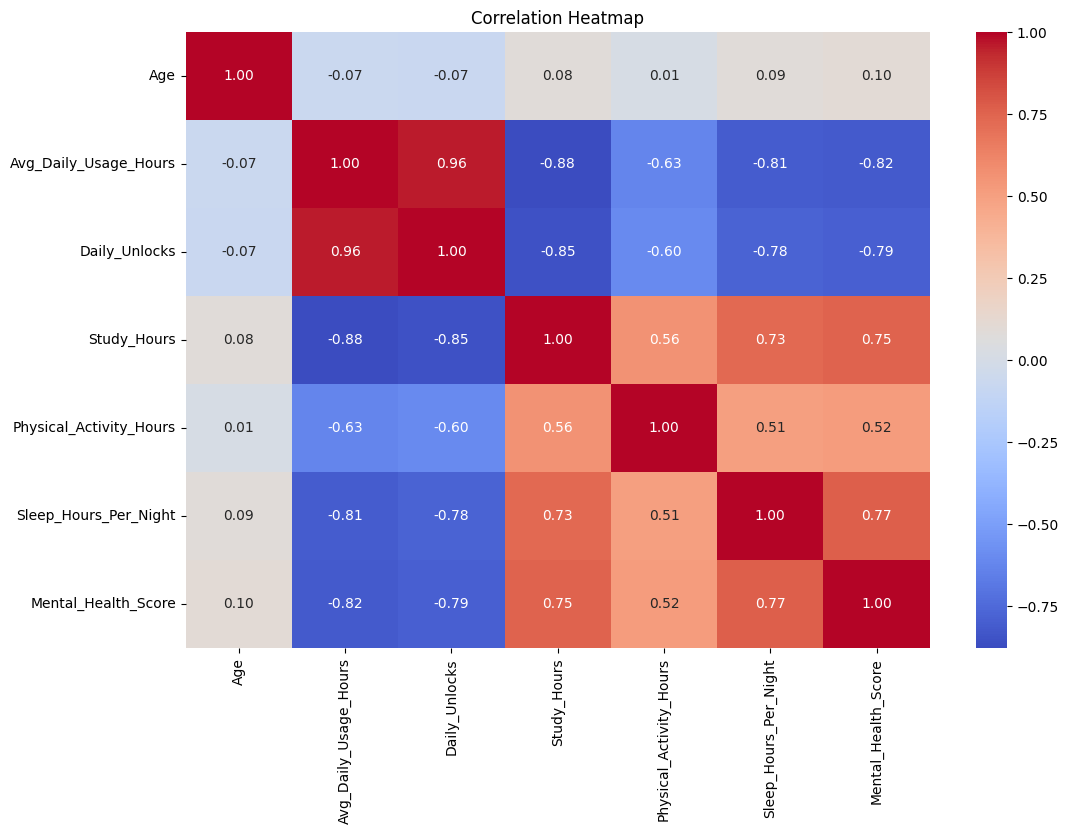

In [8]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

In [9]:
# Stress Level vs Mental Health


Stress Levels:
['Medium' 'Low' 'Very High' 'High']


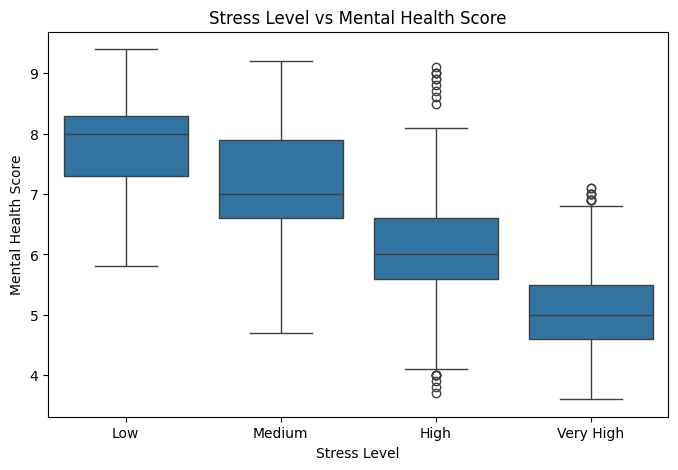

In [10]:
print("\nStress Levels:")
print(df['Stress_Level'].unique())

order = ['Low', 'Medium', 'High', 'Very High']

plt.figure(figsize=(8, 5))

sns.boxplot(
    x='Stress_Level',
    y='Mental_Health_Score',
    data=df,
    order=order
)

plt.title('Stress Level vs Mental Health Score')
plt.xlabel('Stress Level')
plt.ylabel('Mental Health Score')
plt.show()


In [11]:
# Daily Usage vs Mental Health

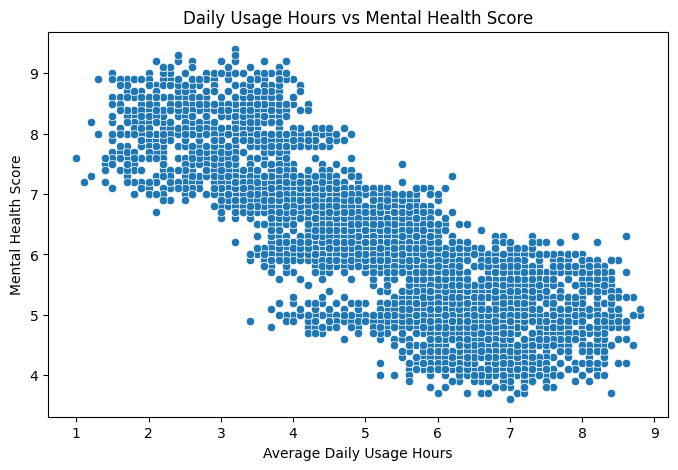

In [12]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x='Avg_Daily_Usage_Hours',
    y='Mental_Health_Score',
    data=df
)

plt.title('Daily Usage Hours vs Mental Health Score')
plt.xlabel('Average Daily Usage Hours')
plt.ylabel('Mental Health Score')
plt.show()


In [13]:
# Sleep Hours vs Mental Health

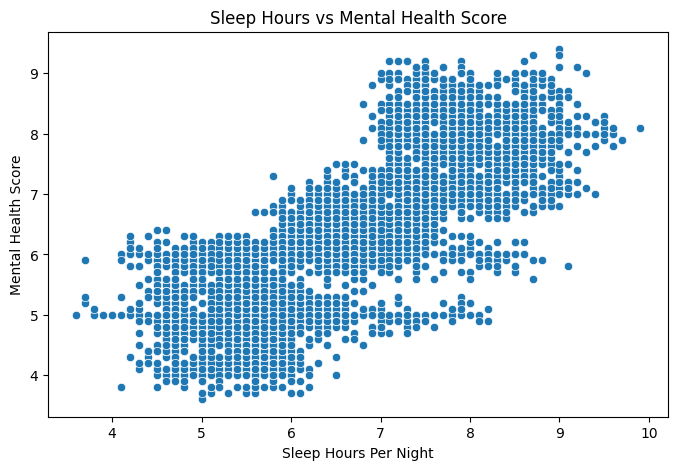

In [14]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x='Sleep_Hours_Per_Night',
    y='Mental_Health_Score',
    data=df
)

plt.title('Sleep Hours vs Mental Health Score')
plt.xlabel('Sleep Hours Per Night')
plt.ylabel('Mental Health Score')
plt.show()

In [16]:
# 4. MOST USED PLATFORM


Dataset Columns:
['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform', 'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night', 'Stress_Level', 'Mental_Health_Score']

Most Used Platforms:
['Facebook' 'LinkedIn' 'Instagram' 'Snapchat' 'Twitter' 'YouTube' 'TikTok'
 'LINE' 'KakaoTalk' 'VKontakte' 'WhatsApp' 'WeChat']

Platform Counts:
Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      523
YouTube       491
Twitter       462
Snapchat      420
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64


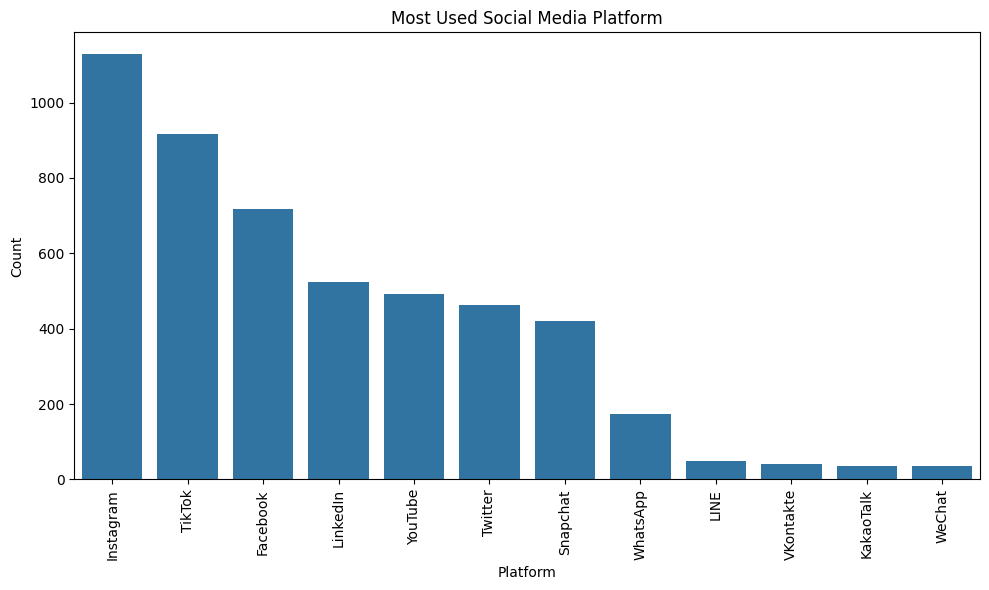

In [17]:
print("\nDataset Columns:")
print(df.columns.tolist())

print("\nMost Used Platforms:")
print(df['Most_Used_Platform'].unique())

platform_counts = df['Most_Used_Platform'].value_counts()

print("\nPlatform Counts:")
print(platform_counts)

plt.figure(figsize=(10, 6))

sns.countplot(
    x='Most_Used_Platform',
    data=df,
    order=platform_counts.index
)

plt.xticks(rotation=90)
plt.title('Most Used Social Media Platform')
plt.xlabel('Platform')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [18]:
# 5. CHECK OUTLIERS

In [19]:
num_features = df.select_dtypes(include='number')

Q1 = num_features.quantile(0.25)
Q3 = num_features.quantile(0.75)

IQR = Q3 - Q1

# CORRECT IQR FORMULA
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (
    (num_features < lower_bound) |
    (num_features > upper_bound)
)

print("\nNumber of Outliers:")
print(outliers.sum())



Number of Outliers:
Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


# 6. DATA CLEANING

In [20]:
print("\nShape before removing duplicates:", df.shape)

# Remove duplicate rows
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)


# -------------------------
# Check negative physical activity
# -------------------------

print("\nNegative Physical Activity Values:")

print(
    df[df['Physical_Activity_Hours'] < 0][
        ['Physical_Activity_Hours']
    ]
)


# Negative physical activity is impossible,
# so replace negative values with 0.

df['Physical_Activity_Hours'] = (
    df['Physical_Activity_Hours'].clip(lower=0)
)


# Check after cleaning
print("\nMinimum Physical Activity Hours:")
print(df['Physical_Activity_Hours'].min())



Shape before removing duplicates: (5000, 13)
Shape after removing duplicates: (4998, 13)

Negative Physical Activity Values:
      Physical_Activity_Hours
2277                     -0.1
2923                     -0.1
3056                     -0.3
3422                     -0.1
3882                     -0.2
4058                     -0.1
4243                     -0.4
4406                     -0.3
4522                     -0.2
4771                     -0.2

Minimum Physical Activity Hours:
0.0


# 7. SKEWNESS ANALYSIS



Numerical Columns:
['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score']

Skewness:
Study_Hours                0.436125
Mental_Health_Score        0.207086
Age                        0.155008
Sleep_Hours_Per_Night      0.123919
Physical_Activity_Hours    0.053288
Avg_Daily_Usage_Hours      0.005575
Daily_Unlocks              0.002309
dtype: float64


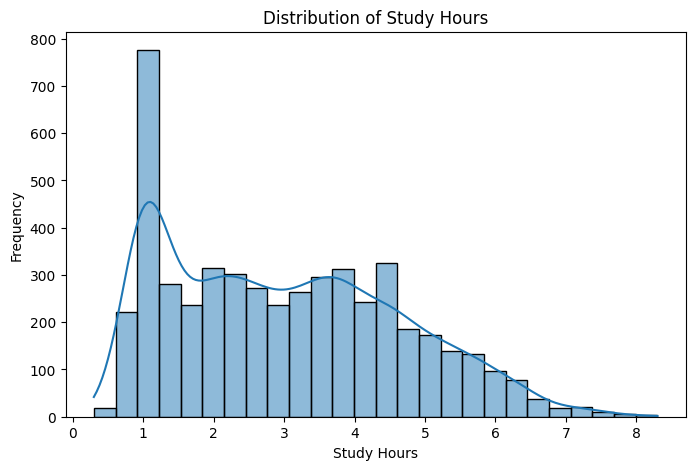

In [21]:
num_cols = df.select_dtypes(include='number')

print("\nNumerical Columns:")
print(num_cols.columns.tolist())

print("\nSkewness:")
print(num_cols.skew().sort_values(ascending=False))


# Visualize Study Hours because it is skewed

plt.figure(figsize=(8, 5))

sns.histplot(
    df['Study_Hours'],
    kde=True
)

plt.title('Distribution of Study Hours')
plt.xlabel('Study Hours')
plt.ylabel('Frequency')
plt.show()

# 8. GROUP COUNTRIES

In [23]:
print("\nNumber of unique countries:")
print(df['Country'].nunique())


# Keep only top 10 countries
top_countries = (
    df['Country']
    .value_counts()
    .index[:10]
    .tolist()
)

print("\nTop 10 Countries:")
print(top_countries)


def group_countries(country):

    if country in top_countries:
        return country

    return 'Other'


df['grouped_countries'] = (
    df['Country'].apply(group_countries)
)


print("\nGrouped Countries:")
print(df['grouped_countries'].value_counts())


Number of unique countries:
111

Top 10 Countries:
['Other', 'India', 'USA', 'Canada', 'Australia', 'UK', 'Germany', 'Mexico', 'Turkey', 'France']

Grouped Countries:
grouped_countries
Other        3231
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64


In [26]:
# 9. DEFINE FEATURES

# Skewed numerical features
skew_col = [
    'Study_Hours'
]


# Other numerical features
other_num = [
    'Age',
    'Avg_Daily_Usage_Hours',
    'Daily_Unlocks',
    'Physical_Activity_Hours',
    'Sleep_Hours_Per_Night'
]


# Nominal categorical features
nominal_cols = [
    'Gender',
    'Academic_Level',
    'Most_Used_Platform',
    'Purpose_Of_Use',
    'grouped_countries'
]


# Ordinal categorical features
ordinal_cols = [
    'Stress_Level'
]

# 10. CREATE PREPROCESSING PIPELINES

In [27]:
# Skewed Numerical Pipeline

skewed_pipeline = Pipeline(
    steps=[
        (
            'log_transform',
            FunctionTransformer(np.log1p)
        ),
        (
            'standard_scaler',
            StandardScaler()
        )
    ]
)


# -------------------------
# Normal Numerical Pipeline
# -------------------------

numerical_pipeline = Pipeline(
    steps=[
        (
            'standard_scaler',
            StandardScaler()
        )
    ]
)


# -------------------------
# Ordinal Pipeline
# -------------------------

ordinal_pipeline = Pipeline(
    steps=[
        (
            'ordinal_encoder',
            OrdinalEncoder(
                categories=[
                    ['Low', 'Medium', 'High', 'Very High']
                ]
            )
        )
    ]
)


# -------------------------
# Nominal Pipeline
# -------------------------

nominal_pipeline = Pipeline(
    steps=[
        (
            'ohe',
            OneHotEncoder(
                handle_unknown='ignore'
            )
        )
    ]
)



# 11. COLUMN TRANSFORMER


In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'Skewed Pipeline',
            skewed_pipeline,
            skew_col
        ),

        (
            'Numerical Pipeline',
            numerical_pipeline,
            other_num
        ),

        (
            'Ordinal Pipeline',
            ordinal_pipeline,
            ordinal_cols
        ),

        (
            'Nominal Pipeline',
            nominal_pipeline,
            nominal_cols
        )
    ]
)


print("\nPreprocessor:")
print(preprocessor)



Preprocessor:
ColumnTransformer(transformers=[('Skewed Pipeline',
                                 Pipeline(steps=[('log_transform',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('standard_scaler',
                                                  StandardScaler())]),
                                 ['Study_Hours']),
                                ('Numerical Pipeline',
                                 Pipeline(steps=[('standard_scaler',
                                                  StandardScaler())]),
                                 ['Age', 'Avg_Daily_Usage_Hours',
                                  'Daily_Unlocks', 'Physical_Activity_Hours',
                                  'Sleep_Hours_Per_Night']),
                                ('Ordinal Pipeline',
                                 Pipeline(steps=[('ordinal_encoder',
                                                  OrdinalEn

In [29]:
feature_column = (
    skew_col +
    other_num +
    ordinal_cols +
    nominal_cols
)

print("\nFeatures used:")
print(feature_column)

print("\nNumber of features before encoding:")
print(len(feature_column))


X = df[feature_column]

y = df['Mental_Health_Score']


Features used:
['Study_Hours', 'Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night', 'Stress_Level', 'Gender', 'Academic_Level', 'Most_Used_Platform', 'Purpose_Of_Use', 'grouped_countries']

Number of features before encoding:
12


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=32
)

print("\nTraining Shape:")
print(X_train.shape)

print("\nTesting Shape:")
print(X_test.shape)


Training Shape:
(3998, 12)

Testing Shape:
(1000, 12)


In [31]:
lr_pipeline = Pipeline(
    steps=[
        (
            'preprocessor',
            preprocessor
        ),

        (
            'regression',
            LinearRegression()
        )
    ]
)

In [32]:
lr_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('Skewed Pipeline',
                                                  Pipeline(steps=[('log_transform',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('standard_scaler',
                                                                   StandardScaler())]),
                                                  ['Study_Hours']),
                                                 ('Numerical Pipeline',
                                                  Pipeline(steps=[('standard_scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Avg_Daily_Usage_Hours',
                                                   'Daily_Unlocks',
                                                   'Physical_Acti...
                                                 ('Ordinal Pipeline',
                                                  Pipeline(steps=[('ordinal_encoder',
                                                                   OrdinalEncoder(categories=[['Low',
                                                                                               'Medium',
                                                                                               'High',
                                                                                               'Very '
                                                                                               'High']]))]),
                                                  ['Stress_Level']),
                                                 ('Nominal Pipeline',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Academic_Level',
                                                   'Most_Used_Platform',
                                                   'Purpose_Of_Use',
                                                   'grouped_countries'])])),
                ('regression', LinearRegression())])


LINEAR REGRESSION RESULTS

Training Performance:
R²   : 0.7270
MAE  : 0.5260
RMSE : 0.6682

Testing Performance:
R²   : 0.7375
MAE  : 0.5141
RMSE : 0.6516


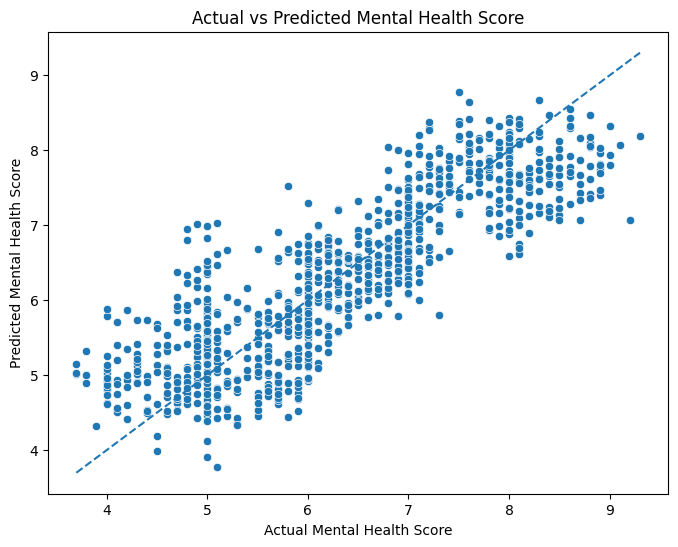

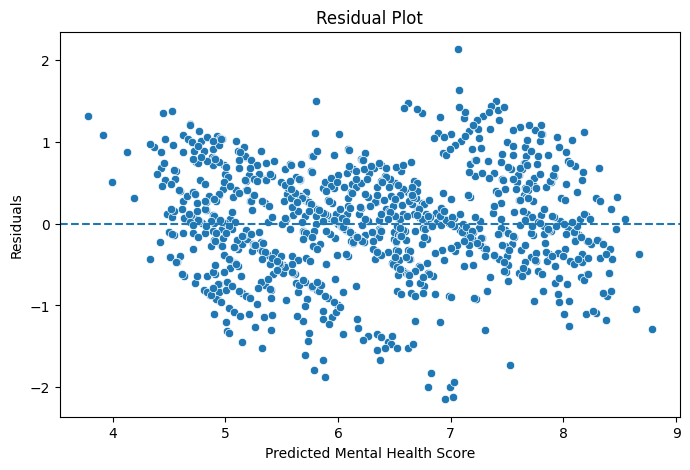


Model saved successfully!
File: Mental_Health_Model.pkl


In [33]:
# Training predictions
lr_pred_train = lr_pipeline.predict(X_train)

# Testing predictions
lr_pred_test = lr_pipeline.predict(X_test)


# ============================================================
# 17. MODEL EVALUATION
# ============================================================

# -------------------------
# Training Metrics
# -------------------------

lr_r2_training = r2_score(
    y_train,
    lr_pred_train
)

lr_mae_training = mean_absolute_error(
    y_train,
    lr_pred_train
)

lr_rmse_training = np.sqrt(
    mean_squared_error(
        y_train,
        lr_pred_train
    )
)


# -------------------------
# Testing Metrics
# -------------------------

lr_r2_testing = r2_score(
    y_test,
    lr_pred_test
)

lr_mae_testing = mean_absolute_error(
    y_test,
    lr_pred_test
)

lr_rmse_testing = np.sqrt(
    mean_squared_error(
        y_test,
        lr_pred_test
    )
)


# ============================================================
# 18. PRINT RESULTS
# ============================================================

print("\n==============================")
print("LINEAR REGRESSION RESULTS")
print("==============================")

print("\nTraining Performance:")
print(f"R²   : {lr_r2_training:.4f}")
print(f"MAE  : {lr_mae_training:.4f}")
print(f"RMSE : {lr_rmse_training:.4f}")


print("\nTesting Performance:")
print(f"R²   : {lr_r2_testing:.4f}")
print(f"MAE  : {lr_mae_testing:.4f}")
print(f"RMSE : {lr_rmse_testing:.4f}")


# ============================================================
# 19. ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=lr_pred_test
)

# Perfect prediction line
min_value = min(y_test.min(), lr_pred_test.min())
max_value = max(y_test.max(), lr_pred_test.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.xlabel('Actual Mental Health Score')
plt.ylabel('Predicted Mental Health Score')
plt.title('Actual vs Predicted Mental Health Score')

plt.show()


# ============================================================
# 20. RESIDUAL ANALYSIS
# ============================================================

residuals = y_test - lr_pred_test

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=lr_pred_test,
    y=residuals
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Predicted Mental Health Score')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.show()


# ============================================================
# 21. SAVE COMPLETE PIPELINE
# ============================================================

joblib.dump(
    lr_pipeline,
    'Mental_Health_Model.pkl'
)

print("\nModel saved successfully!")

print("File: Mental_Health_Model.pkl")